Day 11: Random Forests & Feature Importance.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import time

data = fetch_california_housing()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)
tree_values = [10, 50, 200]

for trees in tree_values:
    start = time.time()
    
    model = RandomForestRegressor(
        n_estimators=trees,
        max_depth=10,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    end = time.time()
    
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    training_time = end - start
    
    print(f"Trees: {trees} | R2 Score: {r2:.4f} | Training Time: {training_time:.4f} sec")


Trees: 10 | R2 Score: 0.7619 | Training Time: 0.7035 sec
Trees: 50 | R2 Score: 0.7733 | Training Time: 4.0412 sec
Trees: 200 | R2 Score: 0.7748 | Training Time: 15.2496 sec


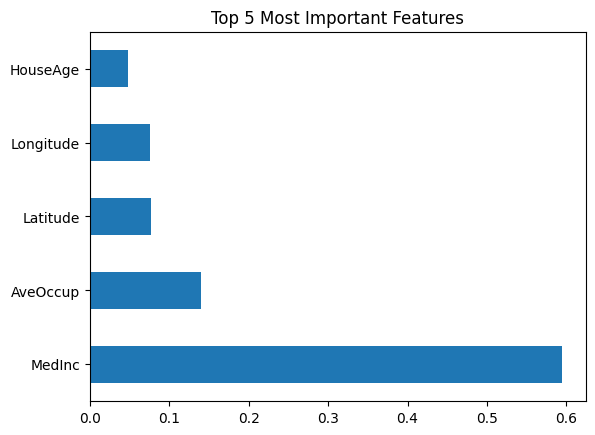

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feature_names = data.feature_names

feat_importances = pd.Series(importances, index=feature_names)

feat_importances.nlargest(5).plot(kind='barh')
plt.title("Top 5 Most Important Features")
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

lr_r2 = r2_score(y_test, lr_predictions)

rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n--- Model Comparison ---")
print(f"Linear Regression R2 Score: {lr_r2:.4f}")
print(f"Random Forest R2 Score: {rf_r2:.4f}")


--- Model Comparison ---
Linear Regression R2 Score: 0.5758
Random Forest R2 Score: 0.7748


Reflection

As we increase the number of trees, does the accuracy keep going up forever, or do we hit a point of 'diminishing returns' where it just takes longer to train for very little gain?


As the number of trees increases, accuracy improves initially due to better stability.However, after a point, the improvement becomes very small while training time keeps increasing. This shows diminishing returns.So, it’s important to choose an optimal number of trees that balances accuracy and efficiency.